In [1]:
import numpy as np
import matplotlib.pyplot as plt
import dtw
import re

from utils.model_selection import ModelSelection, latex_table_high_level_summary
from utils.classification import LogisticRegressionModel, LinearDiscriminantModel, L1RegLogisticRegressionModel,\
    L2RegLogisticRegressionModel
from utils.data import EchocardiographyDataCollection
from utils.evaluation import EvaluationMethods, DtwMethods
from utils.mast_classification import classify_deformation_pattern, classify_collection

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



In [2]:
# load the data and split it into a training and a validation dataset
C = EchocardiographyDataCollection()
_ = C.train_val_split(validation_fraction=0.3, seed=25)

# generate training datasets with linearly interpolated and smoothed resampled strain data
C_lin = C.transform_data_to_common_grid(interpolation='linear', n_time_points=300)
C_smooth = C.transform_data_to_common_grid(interpolation='smoothing splines', n_time_points=300, lam=1e-7)

In [3]:
# compute the deformation pattern classes
dpc = classify_collection(C)

In [4]:
# calculate the features
response = {}
features_raw = {}
features_lin = {}
features_smoothed = {}

for C_, features, coll_name in zip([C, C_lin, C_smooth], 
                                   [features_raw, features_lin, features_smoothed], 
                                   ['(raw)', '(lin.)', '(Smooth. Spl.)']
                                   ):
    
    if len(list(response.keys())) == 0:
        for (group, patient) in C_.keys_to_patients:
            if group not in response.keys():
                response[group] = {}
            response[group][patient] = group

    # established features
    
    f = EvaluationMethods()
    f.evaluate(C_, f.gls)
    features[r'$\mathbf{GLS}$ ' + coll_name] = f.scores

    f = EvaluationMethods()
    f.evaluate(C_, f.systolic_gls)
    features[r'$\mathbf{GLS}_\mathbf{systole}$ ' + coll_name] = f.scores
    
    f = EvaluationMethods()
    f.evaluate(C_, f.mechanical_dispersion)
    features[r'$\mathbf{MD}$ ' + coll_name] = f.scores

    # time difference features
    
    f = EvaluationMethods()
    f.evaluate(C_, f.MaxTI)
    features[r'$MaxTI$ ' + coll_name] = f.scores

    f = EvaluationMethods()
    f.evaluate(C_, f.MaxTM)
    features[r'$MaxTM$ ' + coll_name] = f.scores

    # features based on derivatives of longitudinal strain
    
    f = EvaluationMethods()
    f.evaluate(C_, f.MaxTV)
    features[r'$MaxTV$ ' + coll_name] = f.scores

    f = EvaluationMethods()
    f.evaluate(C_, f.MinMaxTV)
    features[r'$MinMaxTV$ ' + coll_name] = f.scores
    
    f = EvaluationMethods()
    f.evaluate(C_, f.RMSTV)
    features[r'$RMS(TV)$ ' + coll_name] = f.scores

    f = EvaluationMethods()
    f.evaluate(C_, f.MTV_signed)
    features[r'$MeanTV_\text{signed}$ ' + coll_name] = f.scores

    # features centred around peak strain
    
    f = EvaluationMethods()
    f.evaluate(C_, f.peak_strain)
    features[r'$PS$ ' + coll_name] = f.scores

    # features based on deviation from free wall basal strain
    
    f = EvaluationMethods()
    f.evaluate(C_, f.basal_variance)
    features[r'$BV$ ' + coll_name] = f.scores

    # features concerned with aspects of positive strain
    
    f = EvaluationMethods()
    f.evaluate(C_, f.max_positive_value_penalty)
    features[r'$MaxPVP$ ' + coll_name] = f.scores

    f = EvaluationMethods()
    f.evaluate(C_, f.max_positive_peak_penalty)
    features[r'$MaxPPP$ ' + coll_name] = f.scores

    # features that use dynamic time warping

    f = DtwMethods(step_pattern=dtw.symmetricP0, alignment_type='combinations')
    f.evaluate(C_, evaluation_function=f.IV_dtw)
    features[r'$IV_\text{DTW}$ comb. P0 ' + coll_name] = f.scores

    f = DtwMethods(step_pattern=dtw.symmetricP05, alignment_type='combinations')
    f.evaluate(C_, evaluation_function=f.IV_dtw)
    features[r'$IV_\text{DTW}$ comb. P05 ' + coll_name] = f.scores

    f = DtwMethods(step_pattern=dtw.symmetricP1, alignment_type='combinations')
    f.evaluate(C_, evaluation_function=f.IV_dtw)
    features[r'$IV_\text{DTW}$ comb. P1 ' + coll_name] = f.scores

    f = DtwMethods(step_pattern=dtw.symmetricP2, alignment_type='combinations')
    f.evaluate(C_, evaluation_function=f.IV_dtw)
    features[r'$IV_\text{DTW}$ comb. P2 ' + coll_name] = f.scores
    
    f = DtwMethods(step_pattern=dtw.symmetricP0, alignment_type='mean')
    f.evaluate(C_, evaluation_function=f.IV_dtw)
    features[r'$IV_\text{DTW}$ DBA P0 ' + coll_name] = f.scores

    f = DtwMethods(step_pattern=dtw.symmetricP05, alignment_type='mean')
    f.evaluate(C_, evaluation_function=f.IV_dtw)
    features[r'$IV_\text{DTW}$ DBA P05 ' + coll_name] = f.scores
    
    f = DtwMethods(step_pattern=dtw.symmetricP1, alignment_type='mean')
    f.evaluate(C_, evaluation_function=f.IV_dtw)
    features[r'$IV_\text{DTW}$ DBA P1 ' + coll_name] = f.scores
    
    f = DtwMethods(step_pattern=dtw.symmetricP2, alignment_type='mean')
    f.evaluate(C_, evaluation_function=f.IV_dtw)
    features[r'$IV_\text{DTW}$ DBA P2 ' + coll_name] = f.scores
    

    for i, seg_name in C_.segments:

        segment = None
        pattern = r'^.{2}-(.{1}).* (.{1}).*'
        match = re.match(pattern, seg_name)
        if match:
            segment = match.group(1) + '.-' + match.group(2) + '.'
        else:
            raise RuntimeError('Pattern is not matched in `seg_name` string.')

        # segmental time difference features
        
        f = EvaluationMethods()
        f.evaluate(C_, f.TI_segmental(i))
        features[r'$TI$' + f' [{segment}] ' + coll_name] = f.scores

        f = EvaluationMethods()
        f.evaluate(C_, f.TM_segmental(i))
        features[r'$TM$' + f' [{segment}] ' + coll_name] = f.scores
        
        # segmental features based on derivatives of strain
        
        f = EvaluationMethods()
        f.evaluate(C_, f.TV_segmental(i))
        features[r'$TV$' + f' [{segment}] ' + coll_name] = f.scores

        # segmental features concerned with aspects of positive strain
        
        f = EvaluationMethods()
        f.evaluate(C_, f.positive_value_penalty_segmental(i))
        features[r'$PVP$' + f' [{segment}] ' + coll_name] = f.scores

        f = EvaluationMethods()
        f.evaluate(C_, f.positive_peak_penalty_segmental(i))
        features[r'$PPP$' + f' [{segment}] ' + coll_name] = f.scores
        
        # segmental features centred around peak strain
        
        f = EvaluationMethods()
        f.evaluate(C_, f.peak_strain_segmental(i))
        features[r'$PS$' + f' [{segment}] ' + coll_name] = f.scores

        f = EvaluationMethods()
        f.evaluate(C_, f.area_below_peak_strain_segmental(i))
        features[r'$ABPS$' + f' [{segment}] ' + coll_name] = f.scores


In [5]:
# specify the models that should be considered
models = {'logistic regression': LogisticRegressionModel,
          'linear discriminant': LinearDiscriminantModel,
          'l2 reg. log. regression': (L2RegLogisticRegressionModel, {'alpha': np.logspace(-3, 3, num=50)}),
          'l1 reg. log. regression': (L1RegLogisticRegressionModel, {'alpha': np.logspace(-3, 3, num=50)})
         }

# specify the dataset-metric pairs, on which the models should be evaluated
model_selection_metrics = {'raw (AUC)': (features_raw, r'$AUC$'),
                           'linear (AUC)': (features_lin, r'$AUC$'),
                           'smooth (AUC)': (features_smoothed, r'$AUC$'),
                           'raw (ACC_b)': (features_raw, r'$ACC_b(\theta)$'),
                           'linear (ACC_b)': (features_lin, r'$ACC_b(\theta)$'),
                           'smooth (ACC_b)': (features_smoothed, r'$ACC_b(\theta)$')
                           }

model_selections = {}

# now perform the model selection process individually for all the specified model-dataset-metric combinations
for ms_name, (feats, metric_name) in model_selection_metrics.items():
    print(f'Model selection for the `{ms_name}` run:\n')
    
    objective_function = lambda metrics: metrics[metric_name]

    # instantiate the model selection class and run the selection procedure
    ms = ModelSelection(feats, response, models, dpc)
    ms.evaluation(objective_function=objective_function, n_folds=10, verbose=False)

    # choose the optimal model according to the one-standard-error-rule
    ms.find_optimal_models(objective_function, regularisation='1 SE')

    # show some summary statistics and plots
    #ms.summary()
    #ms.plot_scores_best_model(dpc)
    
    model_selections[ms_name] = ms
    
    print('\n\n')

Model selection for the `raw (AUC)` run:



/home/juschi/anaconda3/envs/statistics-env/lib/python3.11/site-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/home/juschi/anaconda3/envs/statistics-env/lib/python3.11/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/juschi/anaconda3/envs/statistics-env/lib/python3.11/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/juschi/anaconda3/envs/statistics-env/lib/python3.11/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=Perfe




Model selection for the `linear (AUC)` run:



/home/juschi/anaconda3/envs/statistics-env/lib/python3.11/site-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/home/juschi/anaconda3/envs/statistics-env/lib/python3.11/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/juschi/anaconda3/envs/statistics-env/lib/python3.11/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/juschi/anaconda3/envs/statistics-env/lib/python3.11/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=Perfe




Model selection for the `smooth (AUC)` run:



...




Model selection for the `linear (ACC_b)` run:



/home/juschi/anaconda3/envs/statistics-env/lib/python3.11/site-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/home/juschi/anaconda3/envs/statistics-env/lib/python3.11/site-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/home/juschi/anaconda3/envs/statistics-env/lib/python3.11/site-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/home/juschi/anaconda3/envs/statistics-env/lib/python3.11/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/juschi/anaconda3/envs/statistics-env/lib/python3.11/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected,




Model selection for the `smooth (ACC_b)` run:



/home/juschi/anaconda3/envs/statistics-env/lib/python3.11/site-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/home/juschi/anaconda3/envs/statistics-env/lib/python3.11/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/juschi/anaconda3/envs/statistics-env/lib/python3.11/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/juschi/anaconda3/envs/statistics-env/lib/python3.11/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=Perfe

/home/juschi/Dokumente/ETH/Masterarbeit/code/github_thesis/utils/classification.py:237: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return stats.pearsonr(x, y).statistic
/home/juschi/Dokumente/ETH/Masterarbeit/code/github_thesis/utils/classification.py:242: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return stats.spearmanr(x, y).statistic
/home/juschi/Dokumente/ETH/Masterarbeit/code/github_thesis/utils/classification.py:237: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return stats.pearsonr(x, y).statistic
/home/juschi/Dokumente/ETH/Masterarbeit/code/github_thesis/utils/classification.py:242: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return stats.spearmanr(x, y).statistic
/home/juschi/Dokumente/ETH/Masterarbeit/code/github_thesis/utils/classification.py:237: ConstantInputWarning: 

In [6]:
# if a latex summary table is desired, then consider making the following function call
latex_table_high_level_summary([(k, v) for k, v in model_selections.items()])

\begin{tabular}{lcccc}
    \toprule
    Model (Dataset) & $ACC_b(\theta^*)$ & $Spec(\theta^*)$ & $Sens(\theta^*)$ & $N_\text{features}$\\
    \midrule
    logistic regression (raw (AUC)) & 0.854 $\pm$ 0.021 & 0.940 $\pm$ 0.032 & 0.768 $\pm$ 0.027 & 4\\
    linear discriminant (raw (AUC)) & 0.871 $\pm$ 0.016 & 0.965 $\pm$ 0.018 & 0.778 $\pm$ 0.034 & 7\\
    l2 reg. log. regression (raw (AUC)) & 0.829 $\pm$ 0.023 & 0.887 $\pm$ 0.045 & 0.771 $\pm$ 0.056 & 63\\
    l1 reg. log. regression (raw (AUC)) & 0.817 $\pm$ 0.024 & 0.919 $\pm$ 0.048 & 0.716 $\pm$ 0.042 & 4\\
    logistic regression (linear (AUC)) & 0.885 $\pm$ 0.021 & 0.926 $\pm$ 0.033 & 0.844 $\pm$ 0.036 & 10\\
    linear discriminant (linear (AUC)) & 0.874 $\pm$ 0.014 & 0.943 $\pm$ 0.029 & 0.805 $\pm$ 0.037 & 15\\
    l2 reg. log. regression (linear (AUC)) & 0.833 $\pm$ 0.022 & 0.949 $\pm$ 0.026 & 0.718 $\pm$ 0.045 & 63\\
    l1 reg. log. regression (linear (AUC)) & 0.842 $\pm$ 0.025 & 0.875 $\pm$ 0.043 & 0.808 $\pm$ 0.038 & 42\\


--- Local evaluation ---
MODEL SELECTION (with 4 models)

Best model: `logistic regression`
;– coefficients ..................... CV est. +- CV SE
|–––––––––––––––––––––––––––––––––––––––––––––––––––––
|– $TV$ [f.-m.] (lin.) .............. -1.820 +- 0.222
|– $MeanTV_\text{signed}$ (lin.) .... -2.002 +- 0.112
|– $TM$ [f.-m.] (lin.) .............. -0.144 +- 0.046
|– $PPP$ [s.-m.] (lin.) .............  2.318 +- 0.105
|– $TI$ [f.-m.] (lin.) .............. -1.414 +- 0.079
|– $MaxTI$ (lin.) ...................  2.856 +- 0.151
|– $TI$ [s.-m.] (lin.) .............. -1.078 +- 0.051
|– $MaxPPP$ (lin.) .................. -2.959 +- 0.163
|– $ABPS$ [f.-a.] (lin.) ............  0.764 +- 0.086
|– $TM$ [s.-b.] (lin.) .............. -0.474 +- 0.089
|– $PS$ [s.-m.] (lin.) .............. -0.424 +- 0.158
|– $TI$ [f.-a.] (lin.) .............. -0.362 +- 0.048
|– $ABPS$ [f.-b.] (lin.) ............ -0.296 +- 0.038
|– $ABPS$ [f.-m.] (lin.) ............  0.121 +- 0.059
|– $TI$ [f.-b.] (lin.) .............. -0.9

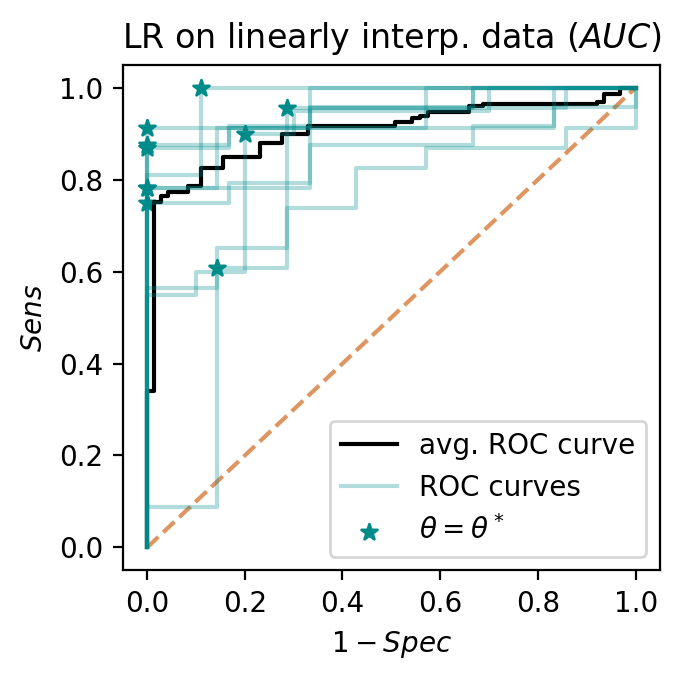

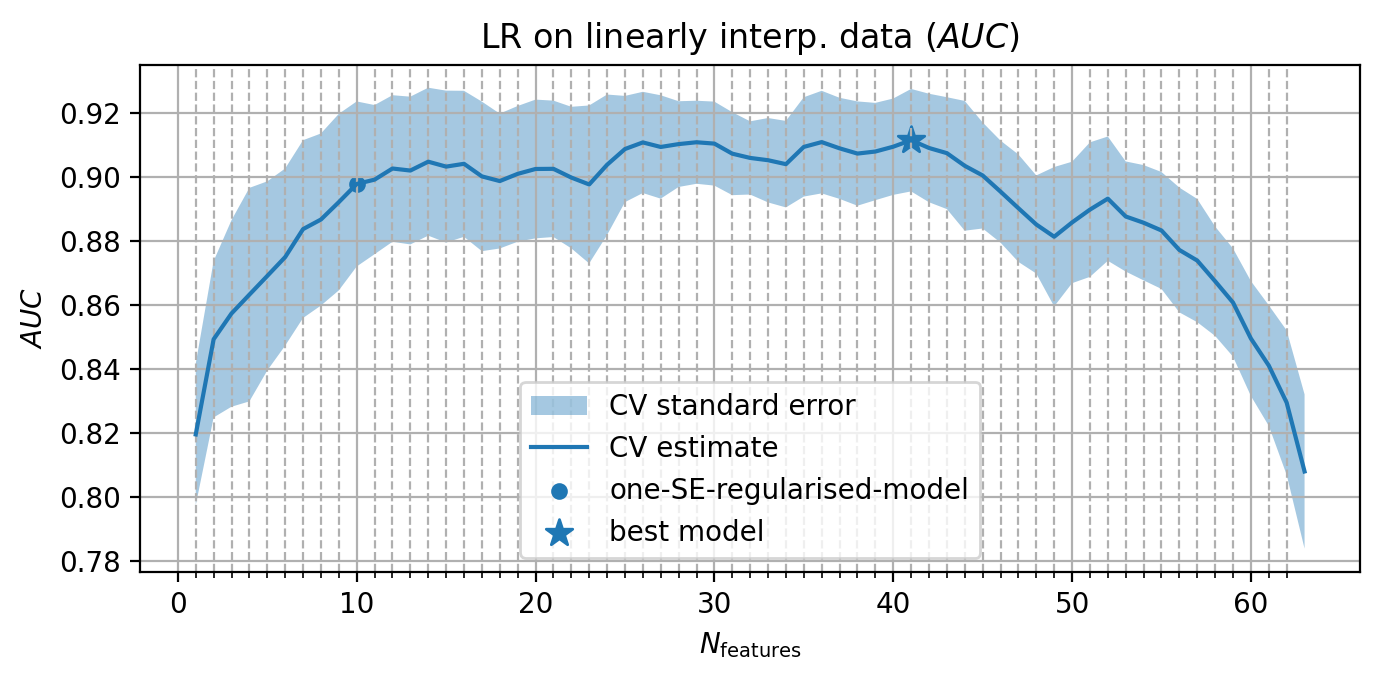

--- Local evaluation ---
MODEL SELECTION (with 4 models)

Best model: `logistic regression`
;– coefficients ............................. CV est. +- CV SE
|–––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
|– $TV$ [f.-m.] (lin.) ...................... -1.282 +- 0.072
|– $MeanTV_\text{signed}$ (lin.) ............ -0.738 +- 0.088
|– $TV$ [s.-b.] (lin.) ...................... -0.764 +- 0.039
|– $TV$ [s.-m.] (lin.) ......................  0.688 +- 0.061
|– $PPP$ [s.-m.] (lin.) .....................  0.405 +- 0.048
|– $PPP$ [f.-m.] (lin.) ..................... -1.442 +- 0.065
|– $PVP$ [f.-m.] (lin.) .....................  1.704 +- 0.085
|– $\mathbf{GLS}_\mathbf{systole}$ (lin.) ... -0.090 +- 0.084
|– $TM$ [f.-m.] (lin.) ......................  0.390 +- 0.035
|– $TV$ [s.-a.] (lin.) ......................  0.143 +- 0.033
|– $TI$ [s.-a.] (lin.) ...................... -0.195 +- 0.010
|– $ABPS$ [s.-a.] (lin.) ....................  0.280 +- 0.035
|– $TI$ [f.-m.] (lin.) ...............

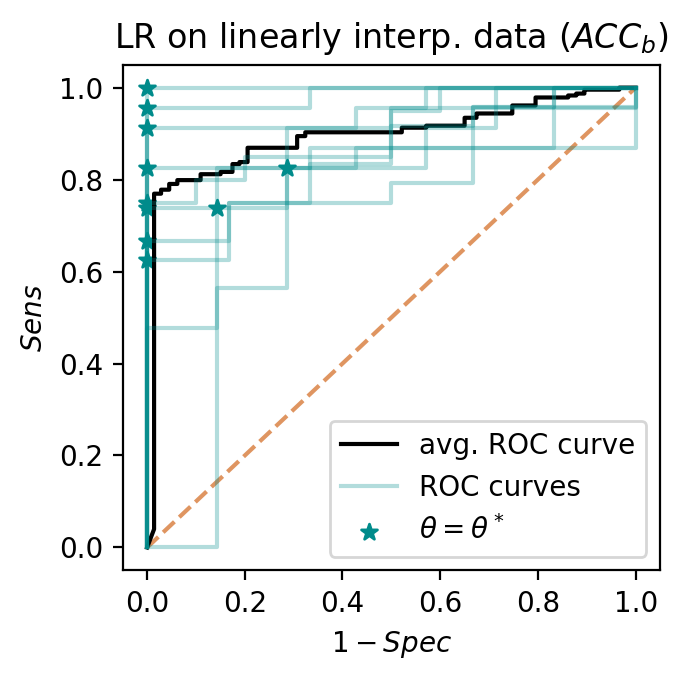

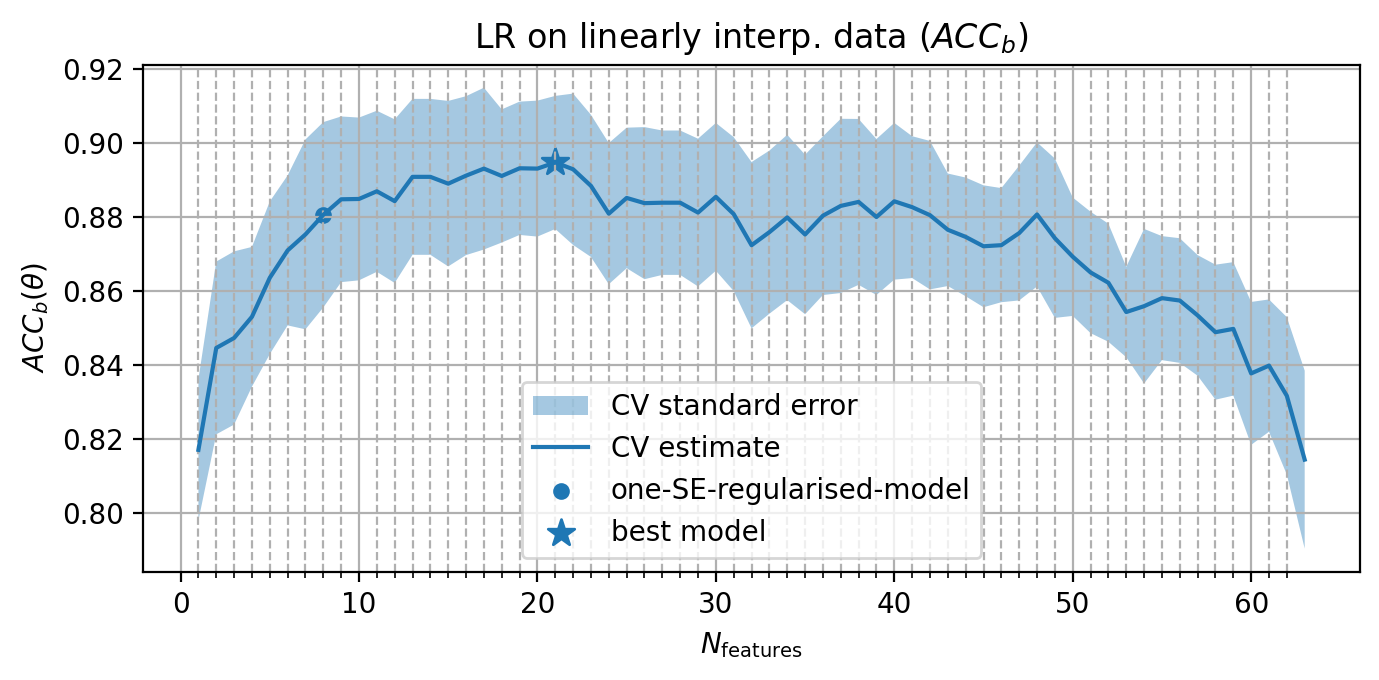

--- Local evaluation ---
MODEL SELECTION (with 4 models)

Best model: `logistic regression`
;– coefficients ............................ CV est. +- CV SE
|––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
|– $TV$ [f.-m.] (Smooth. Spl.) ............. -2.807 +- 0.160
|– $MeanTV_\text{signed}$ (Smooth. Spl.) ... -1.161 +- 0.068
|– $PPP$ [s.-m.] (Smooth. Spl.) ............  0.626 +- 0.058
|– $PS$ [f.-m.] (Smooth. Spl.) ............. -1.625 +- 0.130
|– $TI$ [f.-m.] (Smooth. Spl.) ............. -0.351 +- 0.011
|– $ABPS$ [f.-b.] (Smooth. Spl.) ...........  0.008 +- 0.018
|– $ABPS$ [s.-m.] (Smooth. Spl.) ...........  0.349 +- 0.034
|– $TI$ [f.-b.] (Smooth. Spl.) .............  0.455 +- 0.022
|– $TM$ [s.-a.] (Smooth. Spl.) .............  0.275 +- 0.012
|– $PVP$ [f.-m.] (Smooth. Spl.) ............  0.396 +- 0.036
|– $MaxPVP$ (Smooth. Spl.) .................  0.198 +- 0.083
|– $TM$ [f.-a.] (Smooth. Spl.) ............. -0.072 +- 0.029
|– $TM$ [s.-m.] (Smooth. Spl.) .............  0.228 

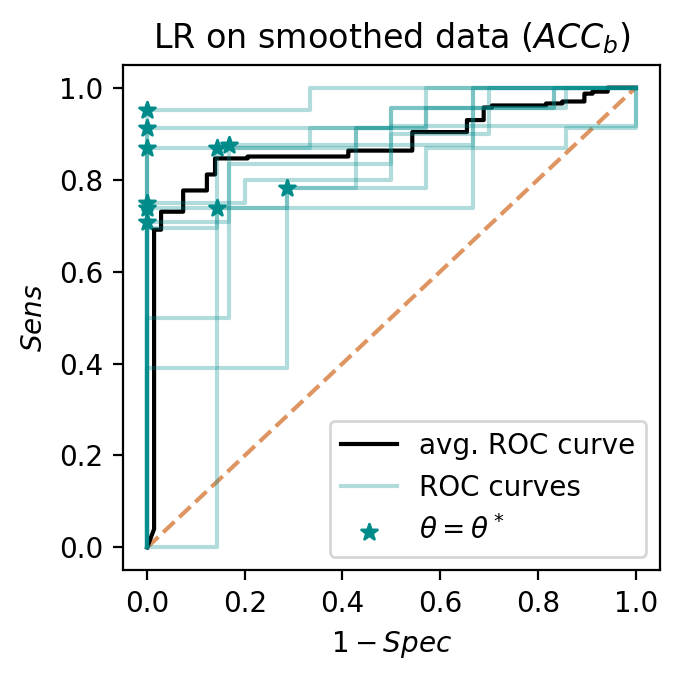

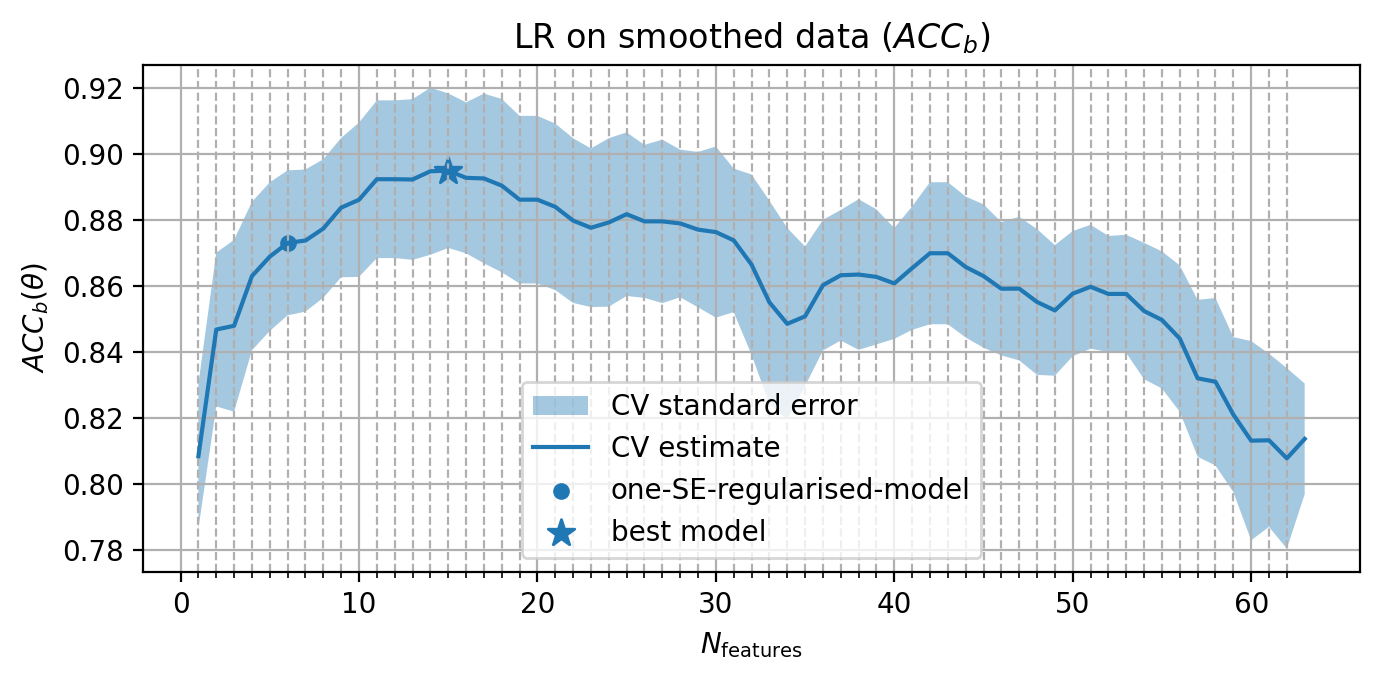

In [7]:
# based on the table above it is possible to select three promising models and display more
# information about them
best_three_selections = [('logistic regression', 'linear (AUC)', r'$AUC$'),
                         ('logistic regression', 'linear (ACC_b)', r'$ACC_b(\theta)$'),
                         ('logistic regression', 'smooth (ACC_b)', r'$ACC_b(\theta)$')
                         ]
titles = [r'LR on linearly interp. data ($AUC$)',
          r'LR on linearly interp. data ($ACC_b$)',
          r'LR on smoothed data ($ACC_b$)'
          ]

for (model_name, ms_name, metric_name), title in zip(best_three_selections, titles):
    ms = model_selections[ms_name]
    
    ms.find_optimal_models(objective_function)
    ms.summary()
    
    ms.find_optimal_models(objective_function, regularisation='1 SE')
    # produce a model specific summary table and save it in the current working directory
    ms.produce_latex_table(model_name, '_'.join((model_name + ' ' + ms_name).split(' ')))
    # produce a the cross-validated ROC curves and an average for the average one
    ms.plot_roc_curves_best_model(model_name,
                                  dpi=200, 
                                  fig_name=title, 
                                  figsize=(3.5,3.5), 
                                  show_intercept=False
                                  )
    # show the evolution of cross-validated generalisation error as a function of the model complexity
    ms.performance_complexity_plot(model_name=model_name,
                                   objective_function=lambda metrics: metrics[metric_name],
                                   maximum=True,
                                   dpi=200,
                                   figsize=(7, 3.5)
                                  )
    plt.ylabel(metric_name)
    plt.xlabel(r'$N_\text{features}$')
    plt.title(title)
    plt.tight_layout()
    plt.show()